# Exploratory Data Analysis (EDA) of Big Mart Sales

**Notebook:** `EDA_Project_SamirPaul.ipynb`  
**Dataset:** `big_mart_sales.csv`

## Project Objective
This notebook follows the project instructions and covers dataset justification, data loading, cleaning, descriptive statistics, visual analysis, group analysis, advanced Python usage, and business insights.

## 1. Import Libraries and Set Options
We begin with standard Python libraries for data analysis and visualization.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

In [6]:
file_path = "big_mart_sales.csv"
df = pd.read_csv(file_path)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Dataset shape: 8523 rows x 12 columns


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.02,Dairy,249.81,OUT049,1999,Medium,Tier 1,Supermarket Type1,"3,735.14"
1,DRC01,5.92,Regular,0.02,Soft Drinks,48.27,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42
2,FDN15,17.50,Low Fat,0.02,Meat,141.62,OUT049,1999,Medium,Tier 1,Supermarket Type1,"2,097.27"
3,FDX07,19.20,Regular,0.00,Fruits and Vegetables,182.09,OUT010,1998,NaN,Tier 3,Grocery Store,732.38
4,NCD19,8.93,Low Fat,0.00,Household,53.86,OUT013,1987,High,Tier 3,Supermarket Type1,994.71


## 3. Initial Data Inspection
As required in the instructions, inspect columns, data types, summary statistics, missing values, and duplicates.

In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nNumerical summary:")
display(df.describe().T)

print("\nCategorical summary:")
display(df.describe(include="object").T)

print(f"\nDuplicate rows: {df.duplicated().sum()}")

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)
missing_summary.head()
#display(missing_summary[missing_summary["missing_count"] > 0])

Columns:
['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']

Data types:


,dtype
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object



Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Item_Weight,"7,060.00",12.86,4.64,4.55,8.77,12.60,16.85,21.35
Item_Visibility,"8,523.00",0.07,0.05,0.00,0.03,0.05,0.09,0.33
Item_MRP,"8,523.00",140.99,62.28,31.29,93.83,143.01,185.64,266.89
Outlet_Establishment_Year,"8,523.00","1,997.83",8.37,"1,985.00","1,987.00","1,999.00","2,004.00","2,009.00"
Item_Outlet_Sales,"8,523.00","2,181.29","1,706.50",33.29,834.25,"1,794.33","3,101.30","13,086.96"



Categorical summary:


,count,unique,top,freq
Item_Identifier,8523,1559,FDW13,10
Item_Fat_Content,8523,5,Low Fat,5089
Item_Type,8523,16,Fruits and Vegetables,1232
Outlet_Identifier,8523,10,OUT027,935
Outlet_Size,6113,3,Medium,2793
Outlet_Location_Type,8523,3,Tier 3,3350
Outlet_Type,8523,4,Supermarket Type1,5577



Duplicate rows: 0


,missing_count,missing_percent
Outlet_Size,2410,28.28
Item_Weight,1463,17.17
Item_Identifier,0,0.00
Item_Fat_Content,0,0.00
Item_Visibility,0,0.00


## 4. Data Quality Observations
Before cleaning, the dataset shows missing values in `Item_Weight` and `Outlet_Size`, inconsistent labels in `Item_Fat_Content`, and suspicious zero values in `Item_Visibility`.

In [8]:
print(df["Item_Fat_Content"].value_counts())
print(f"Rows with Item_Visibility = 0: {(df['Item_Visibility'] == 0).sum()}")

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Rows with Item_Visibility = 0: 526


## 5. Data Cleaning , Pre-processing. Missing Value Treatment
Cleaning decisions used here:

1. Standardize inconsistent `Item_Fat_Content` labels.
2. Impute `Item_Weight` using item-level median, then overall median.
3. Impute `Outlet_Size` using outlet mapping and group mode.
4. Replace zero `Item_Visibility` with item-level non-zero median, then overall median.
5. Create useful derived features such as `Outlet_Age`, `Item_Category`, `MRP_Band`, and `Visibility_Band`.

In [9]:
df_clean = df.copy()

fat_map = {"LF": "Low Fat", "low fat": "Low Fat", "reg": "Regular"}
df_clean["Item_Fat_Content"] = df_clean["Item_Fat_Content"].replace(fat_map)

#Groups the rows by Item_Identifier.
#For each row, computes the median Item_Weight within that item’s group.
#transform("median") returns a Series the same length as df_clean, where each row gets the median weight of its Item_Identifier.

item_weight_median = df_clean.groupby("Item_Identifier")["Item_Weight"].transform("median")

#Looks at Item_Weight and fills missing values (NaN) with the corresponding value from item_weight_median (the median weight of that item).
#So missing weights are first imputed using the item-specific median.
    
df_clean["Item_Weight"] = df_clean["Item_Weight"].fillna(item_weight_median)

# there may still be some NaNs (e.g., if an Item_Identifier only had missing weights).
# This line fills any remaining NaNs in Item_Weight with the overall median of Item_Weight across the whole dataset.

df_clean["Item_Weight"] = df_clean["Item_Weight"].fillna(df_clean["Item_Weight"].median())

outlet_size_map = {"OUT010": "Small", "OUT017": "Small", "OUT045": "Small"}
df_clean["Outlet_Size"] = df_clean["Outlet_Size"].fillna(df_clean["Outlet_Identifier"].map(outlet_size_map))

def fill_with_group_mode(series):
    mode_series = series.mode()
    return mode_series.iloc[0] if not mode_series.empty else np.nan

group_mode = df_clean.groupby(["Outlet_Type", "Outlet_Location_Type"])["Outlet_Size"].transform(
    lambda x: x.fillna(fill_with_group_mode(x))
)
df_clean["Outlet_Size"] = df_clean["Outlet_Size"].fillna(group_mode)
df_clean["Outlet_Size"] = df_clean["Outlet_Size"].fillna(df_clean["Outlet_Size"].mode()[0])



In [10]:
non_zero_visibility = df_clean["Item_Visibility"].replace(0, np.nan)
visibility_median = df_clean.assign(Item_Visibility_NZ=non_zero_visibility).groupby("Item_Identifier")["Item_Visibility_NZ"].transform("median")
df_clean["Item_Visibility"] = df_clean["Item_Visibility"].replace(0, np.nan)
df_clean["Item_Visibility"] = df_clean["Item_Visibility"].fillna(visibility_median)
df_clean["Item_Visibility"] = df_clean["Item_Visibility"].fillna(df_clean["Item_Visibility"].median())

df_clean["Outlet_Age"] = 2026 - df_clean["Outlet_Establishment_Year"]
df_clean["Item_Category"] = df_clean["Item_Identifier"].str[:2].map({"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"})
df_clean.loc[df_clean["Item_Category"] == "Non-Consumable", "Item_Fat_Content"] = "Non-Edible"
df_clean["MRP_Band"] = pd.qcut(df_clean["Item_MRP"], 4, labels=["Low", "Medium", "High", "Very High"])
df_clean["Visibility_Band"] = pd.qcut(df_clean["Item_Visibility"], 4, labels=["Low", "Medium", "High", "Very High"])

print("Missing values after cleaning:")
display(df_clean.isna().sum().to_frame("missing_count").query("missing_count > 0"))

Missing values after cleaning:


,missing_count


## 6. Descriptive Statistics for Numerical Variables

In [11]:
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
num_summary = df_clean[num_cols].describe().T
num_summary["range"] = num_summary["max"] - num_summary["min"]
num_summary["skew"] = df_clean[num_cols].skew()
display(num_summary)

,count,mean,std,min,25%,50%,75%,max,range,skew
Item_Weight,"8,523.00",12.88,4.65,4.55,8.79,12.65,16.85,21.35,16.80,0.07
Item_Visibility,"8,523.00",0.07,0.05,0.00,0.03,0.06,0.10,0.33,0.32,1.21
Item_MRP,"8,523.00",140.99,62.28,31.29,93.83,143.01,185.64,266.89,235.60,0.13
Outlet_Establishment_Year,"8,523.00","1,997.83",8.37,"1,985.00","1,987.00","1,999.00","2,004.00","2,009.00",24.00,-0.40
Item_Outlet_Sales,"8,523.00","2,181.29","1,706.50",33.29,834.25,"1,794.33","3,101.30","13,086.96","13,053.67",1.18
Outlet_Age,"8,523.00",28.17,8.37,17.00,22.00,27.00,39.00,41.00,24.00,0.40


## 7. Descriptive Statistics for Categorical Variables

In [12]:
cat_cols = df_clean.select_dtypes(include="object").columns.tolist() + ["MRP_Band", "Visibility_Band"]
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    display(df_clean[col].value_counts(dropna=False).to_frame("count"))


Value counts for Item_Identifier:


,count
Item_Identifier,
FDW13,10
FDG33,10
NCY18,9
FDD38,9
DRE49,9
...,...
FDY43,1
FDQ60,1
FDO33,1



Value counts for Item_Fat_Content:


,count
Item_Fat_Content,
Low Fat,3918
Regular,3006
Non-Edible,1599



Value counts for Item_Type:


...

,count
Item_Category,
Food,6125
Non-Consumable,1599
Drinks,799



Value counts for MRP_Band:


,count
MRP_Band,
Low,2131
Medium,2131
Very High,2131
High,2130



Value counts for Visibility_Band:


,count
Visibility_Band,
Low,2131
Medium,2131
Very High,2131
High,2130


## 8. Advanced Python Techniques
This section explicitly demonstrates list comprehension, lambda function, and a user-defined function.

In [8]:
numeric_cols_via_list_comp = [col for col in df_clean.columns if df_clean[col].dtype != "object" and str(df_clean[col].dtype) != "category"]
print("Numeric columns using list comprehension:")
print(numeric_cols_via_list_comp)

df_clean["High_Sales_Flag"] = df_clean["Item_Outlet_Sales"].apply(lambda x: "High" if x >= df_clean["Item_Outlet_Sales"].median() else "Low")

def summarize_category(dataframe, column_name):
    summary = pd.DataFrame({
        "count": dataframe[column_name].value_counts(dropna=False),
        "percent": dataframe[column_name].value_counts(normalize=True, dropna=False) * 100
    })
    return summary

display(summarize_category(df_clean, "High_Sales_Flag"))

Numeric columns using list comprehension:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Outlet_Age']


,count,percent
High_Sales_Flag,,
High,4266,50.05
Low,4257,49.95


## 9. Univariate Analysis for Numerical Variables

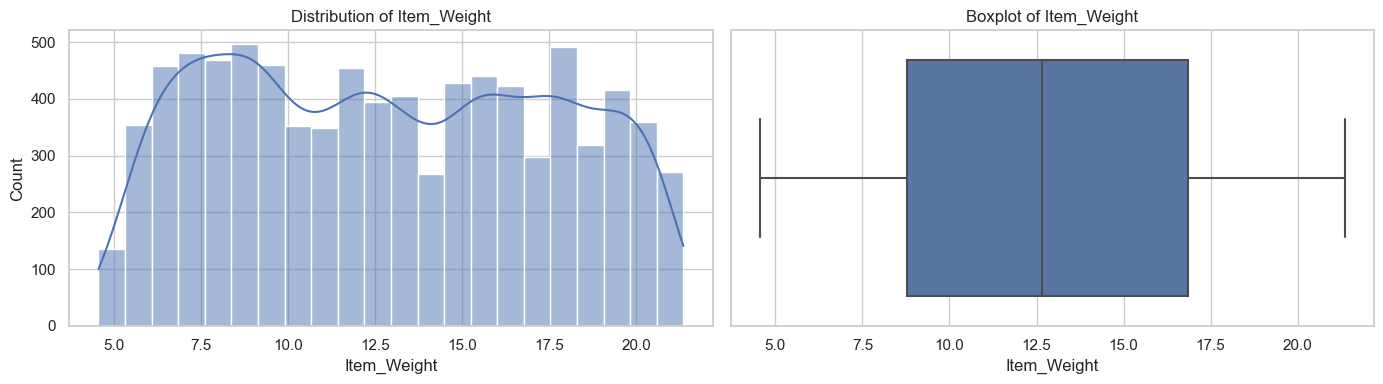

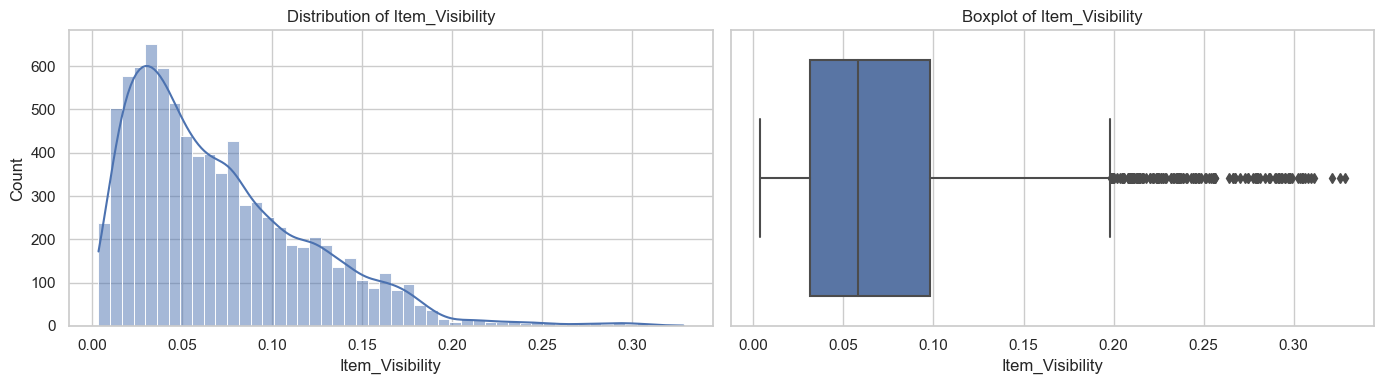

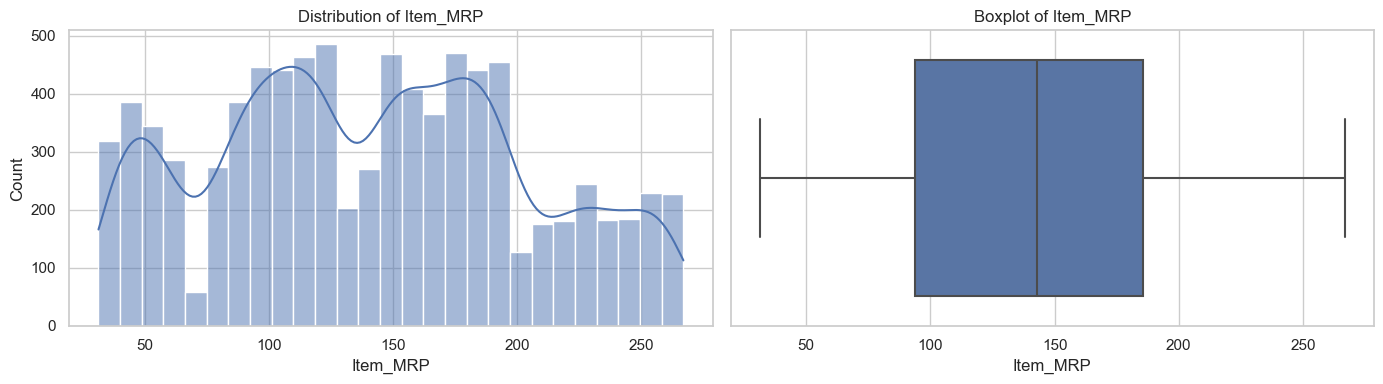

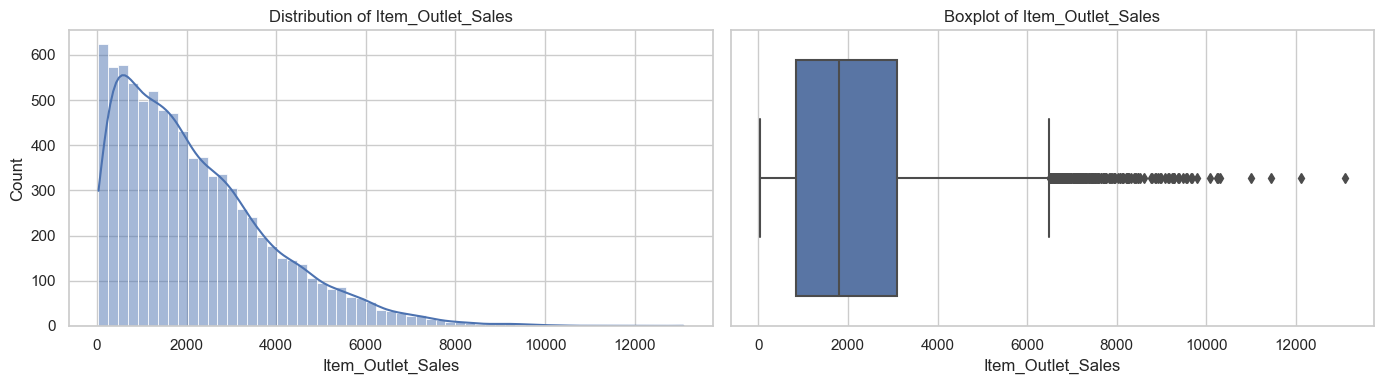

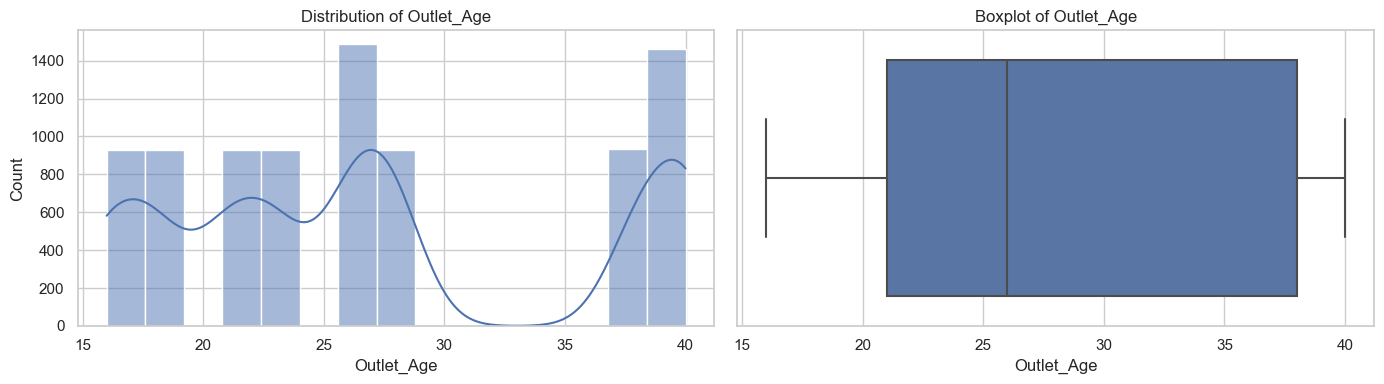

In [9]:
for col in ["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Outlet_Sales", "Outlet_Age"]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df_clean[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=df_clean[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

## 10. Univariate Analysis for Categorical Variables

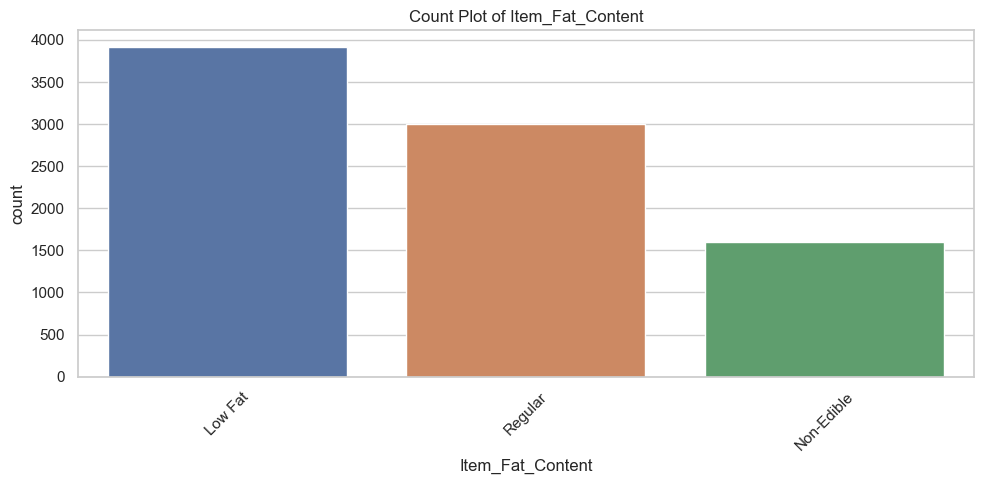

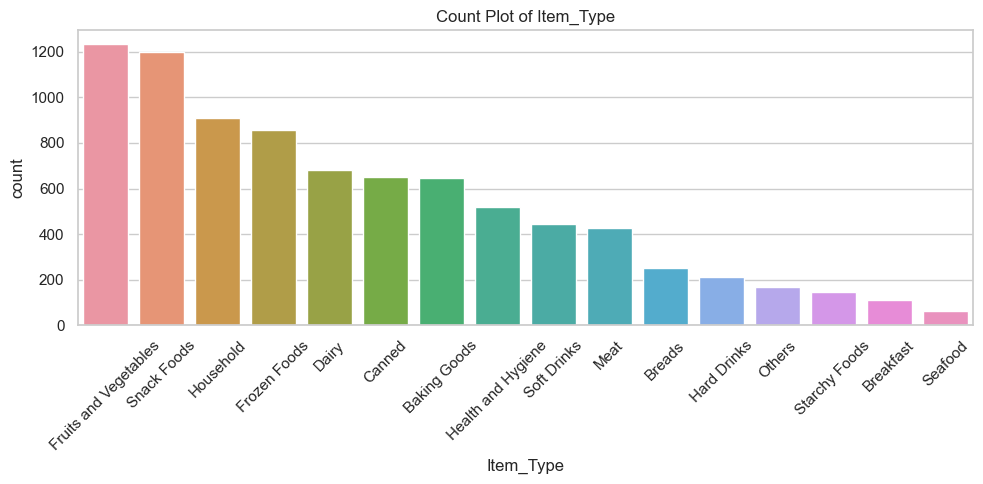

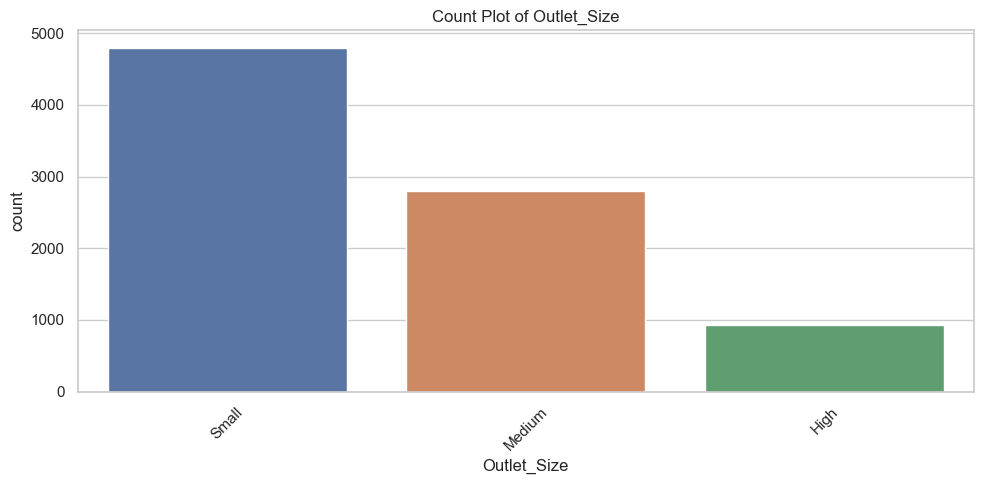

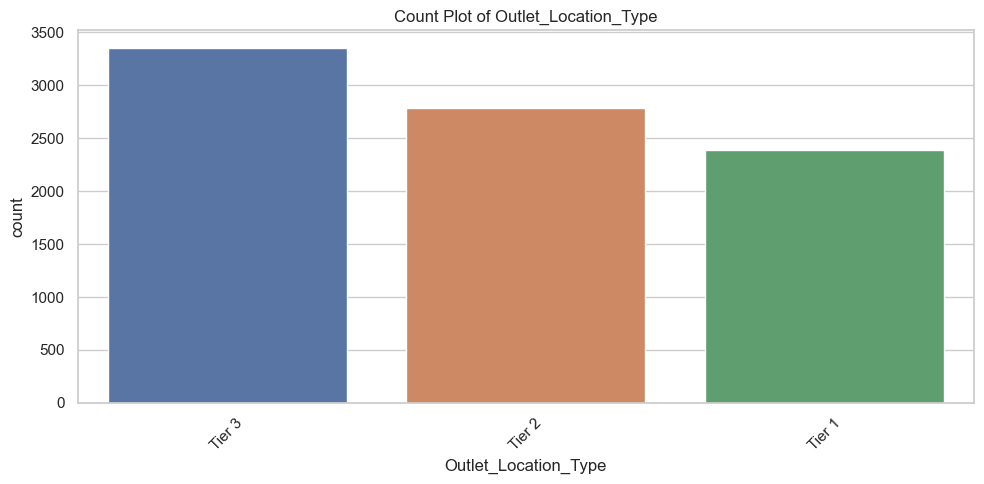

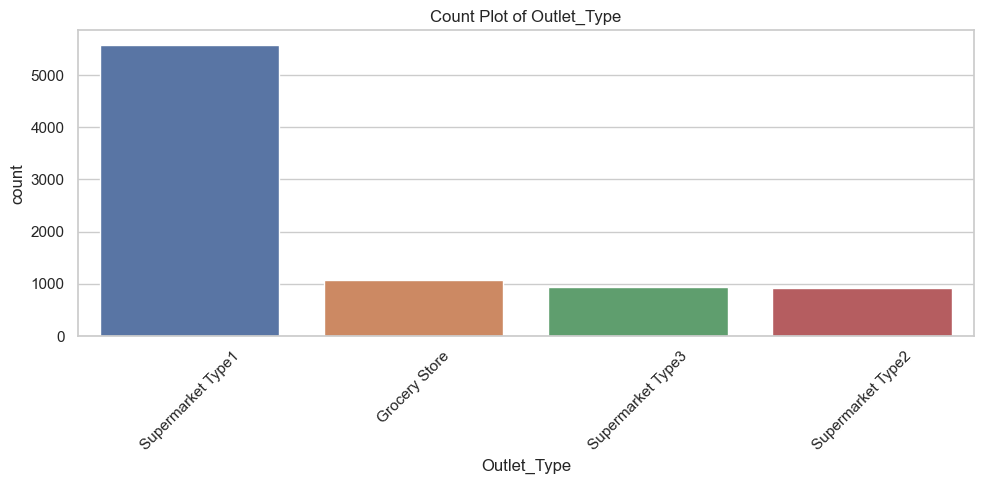

In [10]:
plot_cols = ["Item_Fat_Content", "Item_Type", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]
for col in plot_cols:
    plt.figure(figsize=(10, 5))
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, order=order)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
    plt.tight_layout()
    plt.show()

## 11. Relationship Analysis  - Correlation , Heat Map , Scatter plot
Use correlation, scatter plots, and grouped visuals to study relationships among key variables.

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age
Item_Weight,1.00,-0.02,0.03,0.01,0.01
Item_Visibility,-0.02,1.00,-0.01,-0.13,0.08
Item_MRP,0.03,-0.01,1.00,0.57,-0.01
Item_Outlet_Sales,0.01,-0.13,0.57,1.00,0.05
Outlet_Age,0.01,0.08,-0.01,0.05,1.00


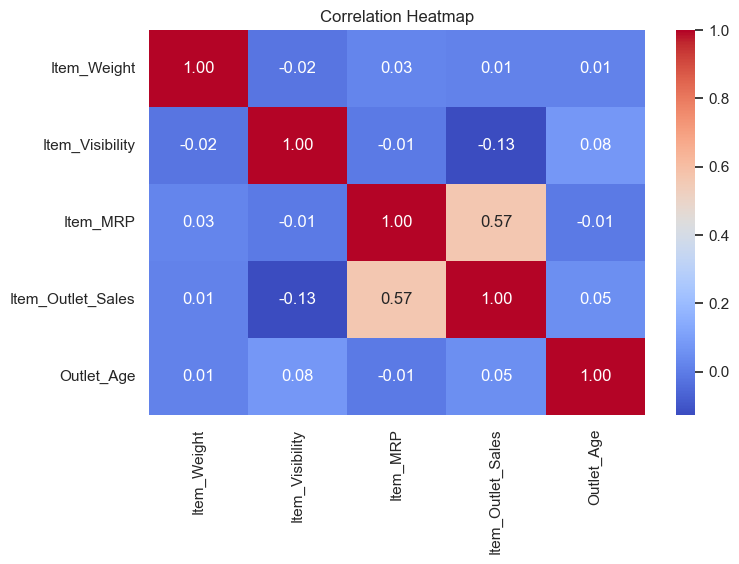

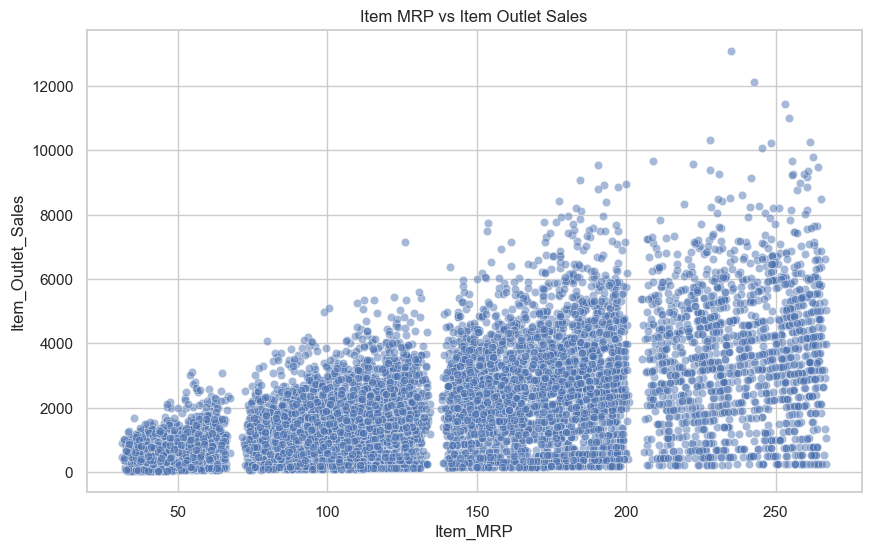

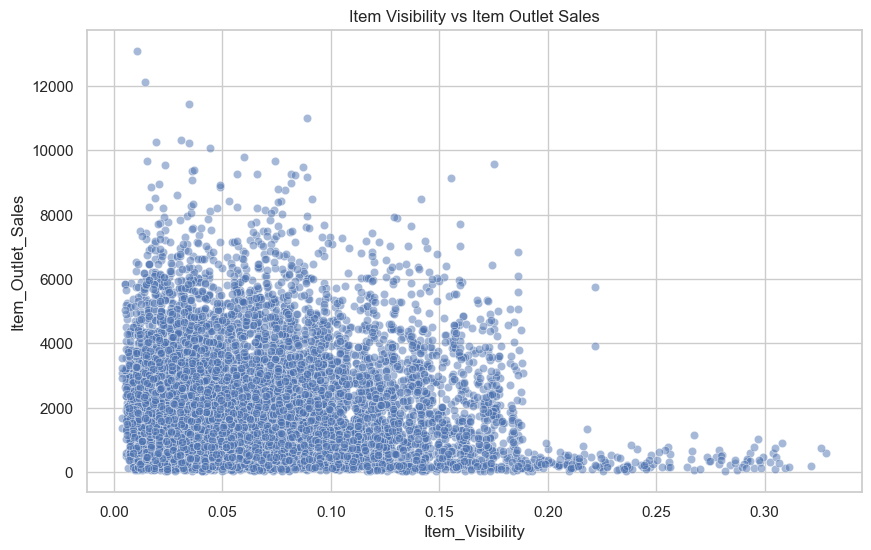

In [11]:
corr_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Outlet_Sales", "Outlet_Age"]
corr_matrix = df_clean[corr_cols].corr()
display(corr_matrix)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(data=df_clean, x="Item_MRP", y="Item_Outlet_Sales", alpha=0.5)
plt.title("Item MRP vs Item Outlet Sales")
plt.show()

sns.scatterplot(data=df_clean, x="Item_Visibility", y="Item_Outlet_Sales", alpha=0.5)
plt.title("Item Visibility vs Item Outlet Sales")
plt.show()

## 12. Group Analysis
The instructions specifically ask for group-by operations and meaningful comparisons across categories.

Sales by Outlet Type


,count,mean,median,sum
Outlet_Type,,,,
Supermarket Type3,935,"3,694.04","3,364.95","3,453,926.05"
Supermarket Type1,5577,"2,316.18","1,990.74","12,917,342.26"
Supermarket Type2,928,"1,995.50","1,655.18","1,851,822.83"
Grocery Store,1083,339.83,257.00,"368,034.27"


Sales by Outlet Location Type


,count,mean,median,sum
Outlet_Location_Type,,,,
Tier 2,2785,"2,323.99","2,004.06","6,472,313.71"
Tier 3,3350,"2,279.63","1,812.31","7,636,752.63"
Tier 1,2388,"1,876.91","1,487.40","4,482,059.07"


Top 10 Item Types by Average Sales


,count,mean,median,sum
Item_Type,,,,
Starchy Foods,148,"2,374.33","1,968.10","351,401.25"
Seafood,64,"2,326.07","2,055.32","148,868.22"
Fruits and Vegetables,1232,"2,289.01","1,830.95","2,820,059.82"
Snack Foods,1200,"2,277.32","1,944.14","2,732,786.09"
Household,910,"2,258.78","1,981.42","2,055,493.71"
Dairy,682,"2,232.54","1,650.85","1,522,594.05"
Canned,649,"2,225.19","1,860.25","1,444,151.49"
Breads,251,"2,204.13","1,860.25","553,237.19"
Meat,425,"2,158.98","1,829.62","917,565.61"


Outlet_Location_Type,Tier 1,Tier 2,Tier 3
Outlet_Type,,,
Grocery Store,340.33,NaN,339.35
Supermarket Type1,"2,313.10","2,323.99","2,299.00"
Supermarket Type2,NaN,NaN,"1,995.50"
Supermarket Type3,NaN,NaN,"3,694.04"


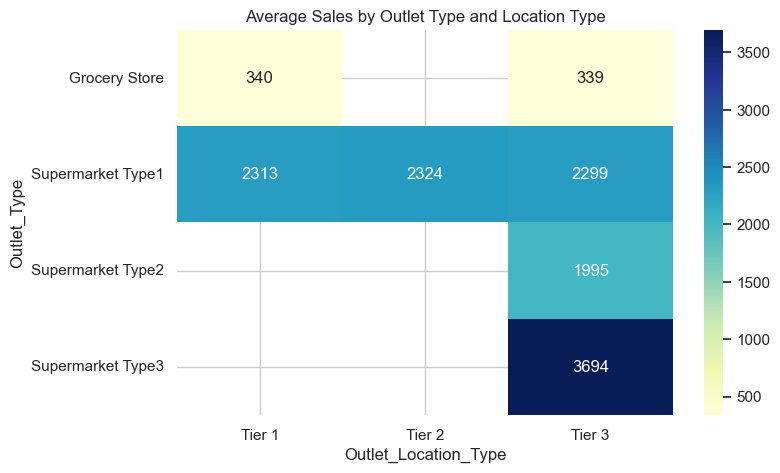

In [12]:
sales_by_outlet_type = df_clean.groupby("Outlet_Type")["Item_Outlet_Sales"].agg(["count", "mean", "median", "sum"]).sort_values("mean", ascending=False)
sales_by_location = df_clean.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].agg(["count", "mean", "median", "sum"]).sort_values("mean", ascending=False)
sales_by_item_type = df_clean.groupby("Item_Type")["Item_Outlet_Sales"].agg(["count", "mean", "median", "sum"]).sort_values("mean", ascending=False)

print("Sales by Outlet Type")
display(sales_by_outlet_type)
print("Sales by Outlet Location Type")
display(sales_by_location)
print("Top 10 Item Types by Average Sales")
display(sales_by_item_type.head(10))

pivot_sales = pd.pivot_table(df_clean, values="Item_Outlet_Sales", index="Outlet_Type", columns="Outlet_Location_Type", aggfunc="mean")
display(pivot_sales)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Sales by Outlet Type and Location Type")
plt.show()

## 13. Key Business Insights and Conclusions

### Key Findings
1. Outlet type is a major driver of sales.
2. Supermarket formats outperform grocery stores on average sales.
3. `Item_MRP` has the strongest positive relationship with sales among the main numerical variables.
4. `Item_Visibility` has a negative relationship with sales in this dataset.
5. Tier 2 and Tier 3 locations perform better than Tier 1 on average sales.
6. Data cleaning was necessary before analysis because missing values, inconsistent labels, and zero visibility values would distort results.

### Potential Next Steps
- Build a regression model for `Item_Outlet_Sales`.
- Encode categorical variables and test feature importance.
- Compare algorithms such as Linear Regression, Random Forest, and XGBoost.

## 14. Final Cleaned Dataset Preview

In [ ]:
display(df_clean.head())
print(f"Final cleaned dataset shape: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")